In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import shap
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_sample_weight

MODELS_DIR    = r"D:\Programs\supply_chain_ai\backend\app\ml"
ENRICHED_PATH = r"D:\Programs\supply_chain_ai\data\maritime_enriched.csv"

In [2]:
df = pd.read_csv(ENRICHED_PATH)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nNull check:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nClass balance:")
print(df["late_delivery_risk"].value_counts(normalize=True).round(3))

Shape: (100000, 29)
Columns: ['shipment_id', 'origin', 'destination', 'distance_km', 'base_time_hrs', 'reliability_score', 'departure_date', 'departure_month', 'departure_year', 'weather_severity_origin', 'weather_severity_route', 'n_restricted_regions', 'n_blocked_regions', 'constraint_penalty', 'passes_suez', 'passes_hormuz', 'passes_malacca', 'passes_bab_el_mandeb', 'passes_cape', 'passes_taiwan_strait', 'passes_south_china_sea', 'is_peak_season', 'is_monsoon_season', 'delay_probability', 'delay_days', 'late_delivery_risk', 'zone_id', 'zone_risk_score', 'anomaly_flag']

Null check:
Series([], dtype: int64)

Class balance:
late_delivery_risk
1    0.642
0    0.358
Name: proportion, dtype: float64


In [3]:
FEATURE_COLS = [
    # Route characteristics
    "distance_km",
    "base_time_hrs",
    "reliability_score",

    # Weather
    "weather_severity_origin",
    "weather_severity_route",

    # Constraint features — connect to constraint engine
    "n_restricted_regions",
    "n_blocked_regions",
    "constraint_penalty",

    # Chokepoint binary flags — key maritime features
    "passes_suez",
    "passes_hormuz",
    "passes_malacca",
    "passes_bab_el_mandeb",
    "passes_cape",
    "passes_taiwan_strait",
    "passes_south_china_sea",

    # Temporal
    "departure_month",
    "is_peak_season",
    "is_monsoon_season",

    # Unsupervised ML outputs
    "zone_id",
    "zone_risk_score",
    "anomaly_flag",
]

TARGET_CLASS = "late_delivery_risk"
TARGET_REG   = "delay_days"

df_model = df[FEATURE_COLS + [TARGET_CLASS, TARGET_REG]].dropna().copy()

print(f"Features: {len(FEATURE_COLS)}")
print(f"Dataset shape: {df_model.shape}")
print(f"\nNull check — must all be 0:")
print(df_model.isnull().sum())
print(f"\nFeature stats:")
print(df_model[FEATURE_COLS].describe().round(3))

Features: 21
Dataset shape: (100000, 23)

Null check — must all be 0:
distance_km                0
base_time_hrs              0
reliability_score          0
weather_severity_origin    0
weather_severity_route     0
n_restricted_regions       0
n_blocked_regions          0
constraint_penalty         0
passes_suez                0
passes_hormuz              0
passes_malacca             0
passes_bab_el_mandeb       0
passes_cape                0
passes_taiwan_strait       0
passes_south_china_sea     0
departure_month            0
is_peak_season             0
is_monsoon_season          0
zone_id                    0
zone_risk_score            0
anomaly_flag               0
late_delivery_risk         0
delay_days                 0
dtype: int64

Feature stats:
       distance_km  base_time_hrs  reliability_score  weather_severity_origin  \
count   100000.000     100000.000         100000.000               100000.000   
mean     10770.932        335.671              0.798                    

In [4]:
X       = df_model[FEATURE_COLS].copy()
y_class = df_model[TARGET_CLASS].copy()
y_reg   = df_model[TARGET_REG].copy()

X_train, X_test, y_train_c, y_test_c, y_train_r, y_test_r = train_test_split(
    X, y_class, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_c)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")
print(f"Train balance: {y_train_c.value_counts(normalize=True).round(3).to_dict()}")

Train: 80,000 rows
Test:  20,000 rows
Train balance: {1: 0.642, 0: 0.358}


In [5]:
clf = XGBClassifier(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    random_state     = 42,
    eval_metric      = "logloss",
    verbosity        = 0
)

clf.fit(X_train, y_train_c, sample_weight=sample_weights)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [6]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test_c, y_prob)

print(f"Test AUC-ROC: {auc:.4f}")
print(f"\nClassification report:")
print(classification_report(y_test_c, y_pred))

Test AUC-ROC: 0.8410

Classification report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74      7150
           1       0.92      0.72      0.81     12850

    accuracy                           0.78     20000
   macro avg       0.78      0.80      0.77     20000
weighted avg       0.82      0.78      0.78     20000



In [7]:
train_prob = clf.predict_proba(X_train)[:, 1]
train_auc  = roc_auc_score(y_train_c, train_prob)
test_auc   = auc
gap        = train_auc - test_auc

print(f"Train AUC : {train_auc:.4f}")
print(f"Test AUC : {test_auc:.4f}")
print(f"Gap : {gap:.4f}")

Train AUC : 0.8768
Test AUC : 0.8410
Gap : 0.0358


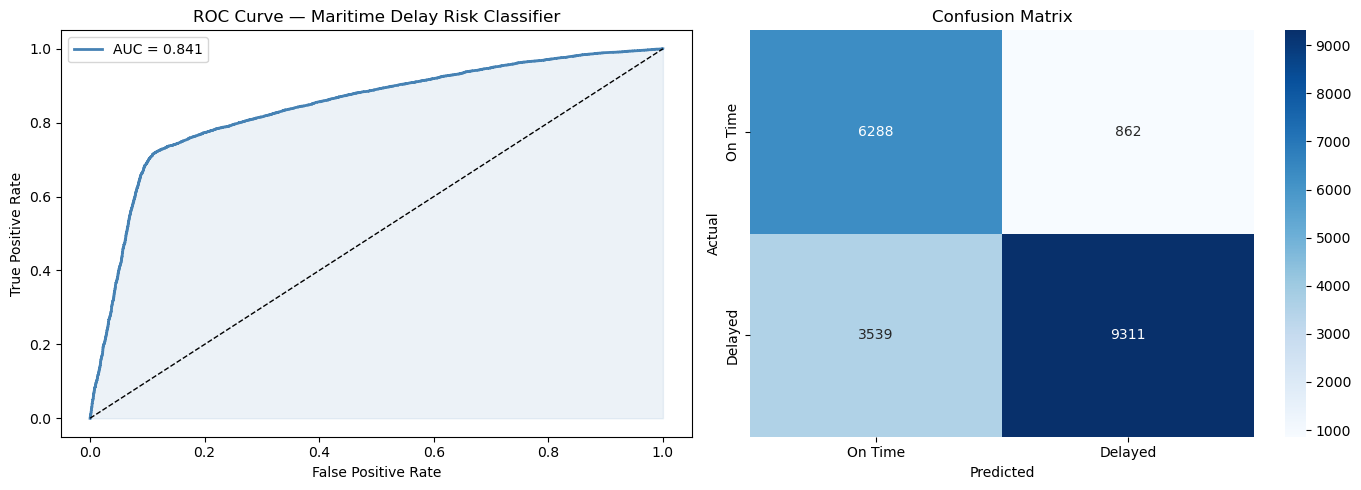

Missed real delays (False Negatives): 3539
False alarms (False Positives): 862


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test_c, y_prob)
axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {test_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color="steelblue")
axes[0].set_title("ROC Curve — Maritime Delay Risk Classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

cm = confusion_matrix(y_test_c, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],xticklabels=["On Time", "Delayed"],yticklabels=["On Time", "Delayed"])
axes[1].set_title("Confusion Matrix")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Missed real delays (False Negatives): {fn}")
print(f"False alarms (False Positives): {fp}")

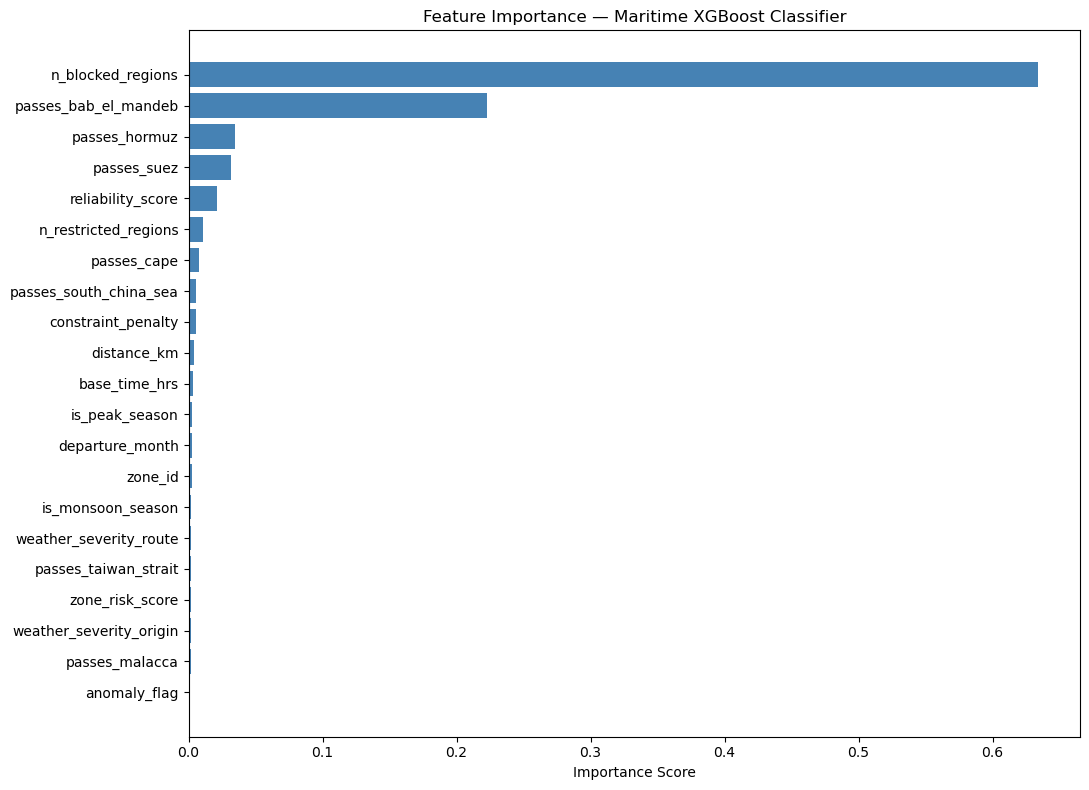

Top 5 features:
             feature  importance
   n_blocked_regions    0.633524
passes_bab_el_mandeb    0.222730
       passes_hormuz    0.034552
         passes_suez    0.031600
   reliability_score    0.021496


In [9]:
importance_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=True)

plt.figure(figsize=(11, 8))
plt.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
plt.title("Feature Importance — Maritime XGBoost Classifier")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importance_df.sort_values("importance", ascending=False).head(5).to_string(index=False))

Computing SHAP values (takes 1-2 minutes on 20k test rows)...


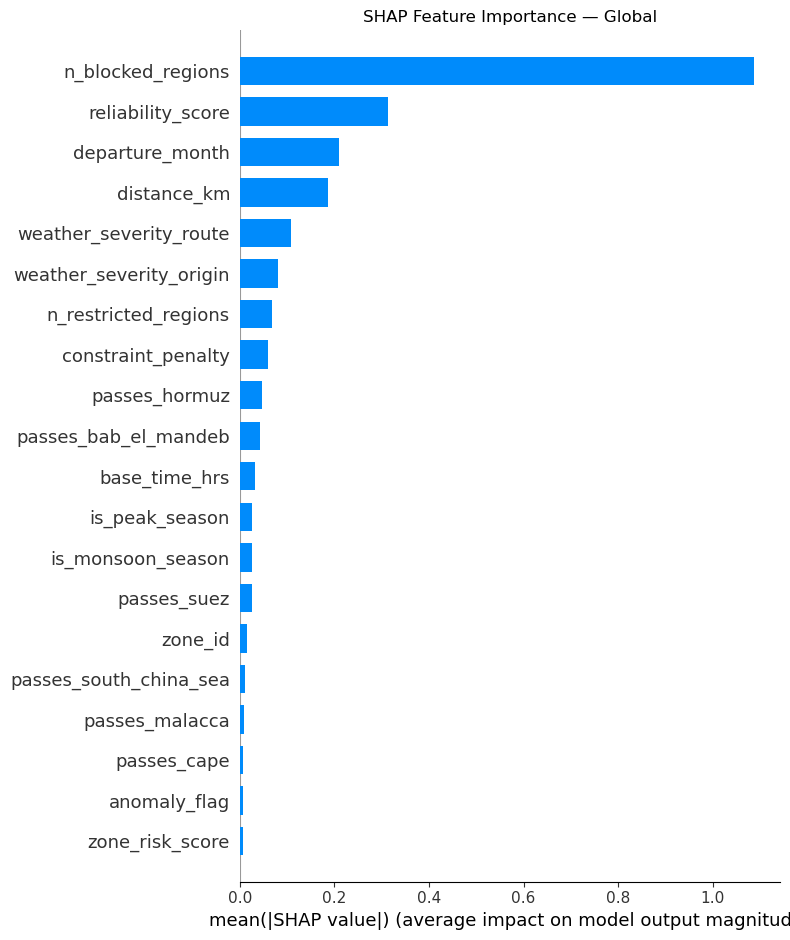

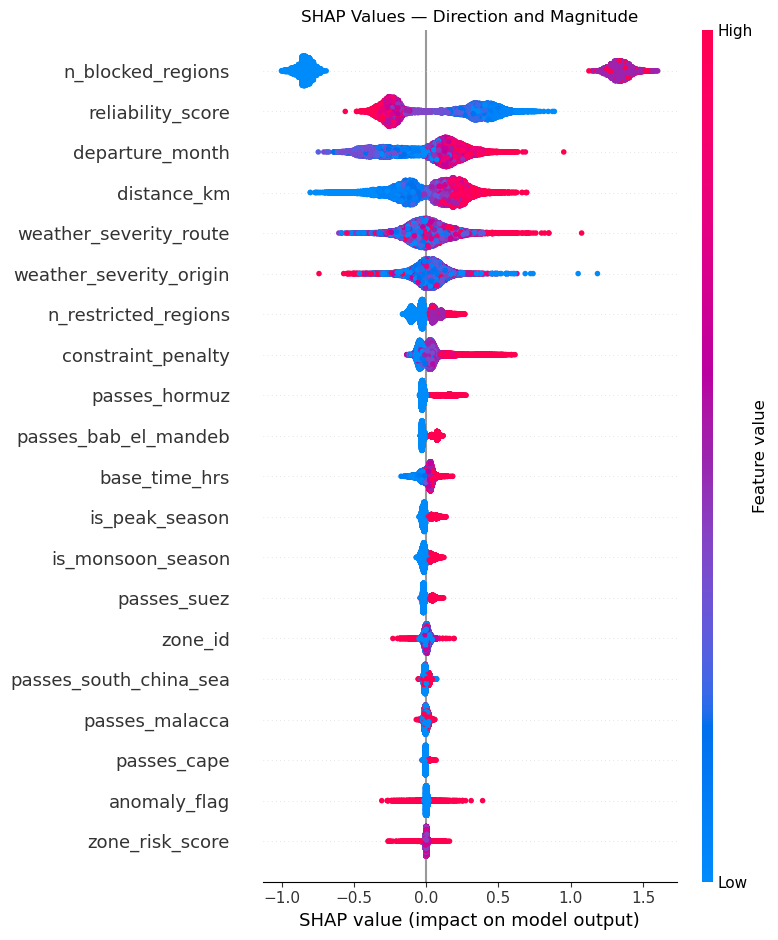


Example explanation for shipment with Hormuz exposure:
Risk score: 0.891

Top SHAP contributions for this shipment:
                feature  shap_value
      n_blocked_regions    1.355218
      reliability_score    0.490405
            distance_km    0.113200
weather_severity_origin    0.101968
          passes_hormuz    0.090536

SHAP explainer saved.


In [10]:
print("Computing SHAP values (takes 1-2 minutes on 20k test rows)...")

# Use TreeExplainer — fastest for XGBoost
explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Global summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Global")
plt.tight_layout()
plt.show()

# Detailed beeswarm plot
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Values — Direction and Magnitude")
plt.tight_layout()
plt.show()

# Single prediction explanation example
sample_idx = X_test[X_test["passes_hormuz"] == 1].index[0]
sample_pos = X_test.index.get_loc(sample_idx)

print(f"\nExample explanation for shipment with Hormuz exposure:")
print(f"Risk score: {y_prob[sample_pos]:.3f}")
print(f"\nTop SHAP contributions for this shipment:")
contrib = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "shap_value":  shap_values[sample_pos]
}).sort_values("shap_value", ascending=False)
print(contrib.head(5).to_string(index=False))

joblib.dump(explainer, os.path.join(MODELS_DIR, "shap_explainer.joblib"))
print(f"\nSHAP explainer saved.")

In [11]:
mask_train = y_train_r > 0
mask_test  = y_test_r > 0

print(f"Training on {mask_train.sum():,} delayed shipments")
print(f"Delay days distribution (train, delayed only):")
print(y_train_r[mask_train].describe().round(2))

reg = XGBRegressor(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    random_state     = 42,
    verbosity        = 0
)

reg.fit(X_train[mask_train], y_train_r[mask_train])

Training on 51,400 delayed shipments
Delay days distribution (train, delayed only):
count    51400.0
mean        14.7
std          8.4
min          0.5
25%          8.5
50%         14.1
75%         19.8
max         69.5
Name: delay_days, dtype: float64


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
y_pred_reg = reg.predict(X_test[mask_test])
train_pred = reg.predict(X_train[mask_train])

mae       = mean_absolute_error(y_test_r[mask_test], y_pred_reg)
rmse      = np.sqrt(mean_squared_error(y_test_r[mask_test], y_pred_reg))
r2        = r2_score(y_test_r[mask_test], y_pred_reg)
train_mae = mean_absolute_error(y_train_r[mask_train], train_pred)

print(f"\nRegressor results:")
print(f"Train MAE : {train_mae:.2f} days  ({train_mae*24:.1f} hrs)")
print(f"Test MAE : {mae:.2f} days  ({mae*24:.1f} hrs)")
print(f"Gap : {mae - train_mae:.2f} days")
print(f"RMSE : {rmse:.2f} days")
print(f"R² : {r2:.4f}")


Regressor results:
Train MAE : 3.92 days  (94.2 hrs)
Test MAE : 4.18 days  (100.3 hrs)
Gap : 0.26 days
RMSE : 5.75 days
R² : 0.5390


In [13]:
joblib.dump(clf, os.path.join(MODELS_DIR, "xgb_classifier.joblib"))
joblib.dump(reg, os.path.join(MODELS_DIR, "xgb_regressor.joblib"))

with open(os.path.join(MODELS_DIR, "feature_cols.json"), "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

model_meta = {
    "classifier_target":    "late_delivery_risk",
    "regressor_target":     "delay_days",
    "regressor_unit":       "days",
    "feature_cols":         FEATURE_COLS,
    "n_features":           len(FEATURE_COLS),
    "training_rows":        int(len(df_model)),
    "classifier_auc":       round(float(test_auc), 4),
    "classifier_gap":       round(float(gap), 4),
    "regressor_mae_days":   round(float(mae), 4),
    "regressor_r2":         round(float(r2), 4),
    "dataset":              "maritime_synthetic_100k",
    "routes_covered":       len(routes) if 'routes' in dir() else 36,
}

with open(os.path.join(MODELS_DIR, "model_meta.json"), "w") as f:
    json.dump(model_meta, f, indent=2)

print("All files saved:")
for fname in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(os.path.join(MODELS_DIR, fname))
    print(f"  {fname:45s}  {size/1024:6.1f} KB")
for k, v in model_meta.items():
    print(f"  {k}: {v}")

All files saved:
  __pycache__                                       0.0 KB
  explainer.py                                      4.0 KB
  feature_cols.json                                 0.5 KB
  features.py                                       6.0 KB
  kmeans_model.joblib                               0.9 KB
  kmeans_scaler.joblib                              0.9 KB
  loader.py                                         0.8 KB
  model_meta.json                                   0.9 KB
  port_zone_lookup.csv                              0.4 KB
  predictor.py                                      1.6 KB
  route_anomaly_baseline.csv                        2.0 KB
  shap_explainer.joblib                          6624.7 KB
  xgb_classifier.joblib                          1948.5 KB
  xgb_classifier.ubj                             1945.1 KB
  xgb_regressor.joblib                           2162.3 KB
  xgb_regressor.ubj                              2159.0 KB
  classifier_target: late_delivery_risk

In [14]:
import xgboost as xgb
import joblib
import os

MODELS_DIR = r"D:\Programs\supply_chain_ai\backend\app\ml"

# Load and resave using native XGBoost format
clf = joblib.load(os.path.join(MODELS_DIR, "xgb_classifier.joblib"))
reg = joblib.load(os.path.join(MODELS_DIR, "xgb_regressor.joblib"))

# Save as native XGBoost binary — no version mismatch
clf.get_booster().save_model(os.path.join(MODELS_DIR, "xgb_classifier.ubj"))
reg.get_booster().save_model(os.path.join(MODELS_DIR, "xgb_regressor.ubj"))

In [15]:
import shap, joblib, os, xgboost as xgb

MODELS_DIR = r"D:\Programs\supply_chain_ai\backend\app\ml"

# Load the fresh booster
clf_fresh = xgb.XGBClassifier()
clf_fresh.load_model(os.path.join(MODELS_DIR, "xgb_classifier.ubj"))

# Rebuild explainer on fresh model
explainer = shap.TreeExplainer(clf_fresh)
joblib.dump(explainer, os.path.join(MODELS_DIR, "shap_explainer.joblib"))
print("SHAP explainer rebuilt on native XGBoost model")

SHAP explainer rebuilt on native XGBoost model
